In [ ]:
# Week 2 Assignment
## End-to-End Machine Learning Pipeline on Tesla Sales Dataset

**Objective**

Build a complete machine learning pipeline including:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print("Shape:", df.shape)

Shape: (2640, 12)


In [4]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [8]:
print(df.duplicated().sum())

0


In [11]:
df = df.drop_duplicates()

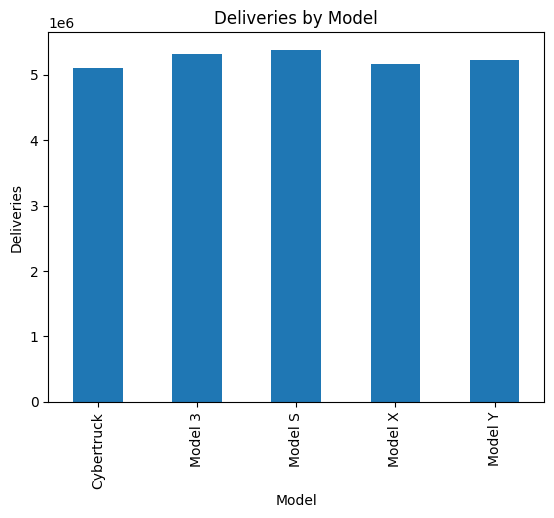

In [10]:
delivery = df.groupby("Model")["Estimated_Deliveries"].sum()

delivery.plot(kind="bar")

plt.title("Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Deliveries")
plt.show()

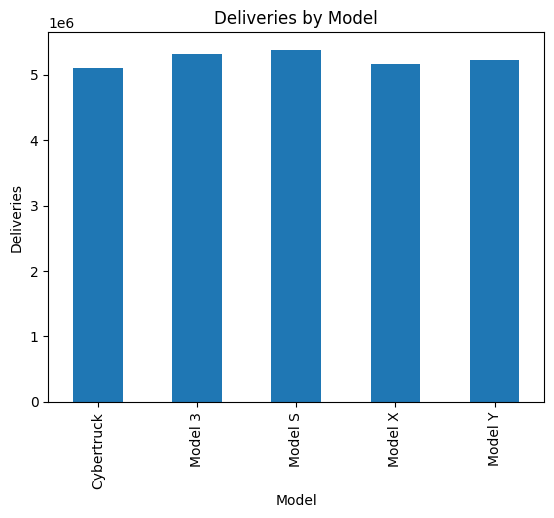

In [12]:
delivery = df.groupby("Model")["Estimated_Deliveries"].sum()

delivery.plot(kind="bar")

plt.title("Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Deliveries")
plt.show()

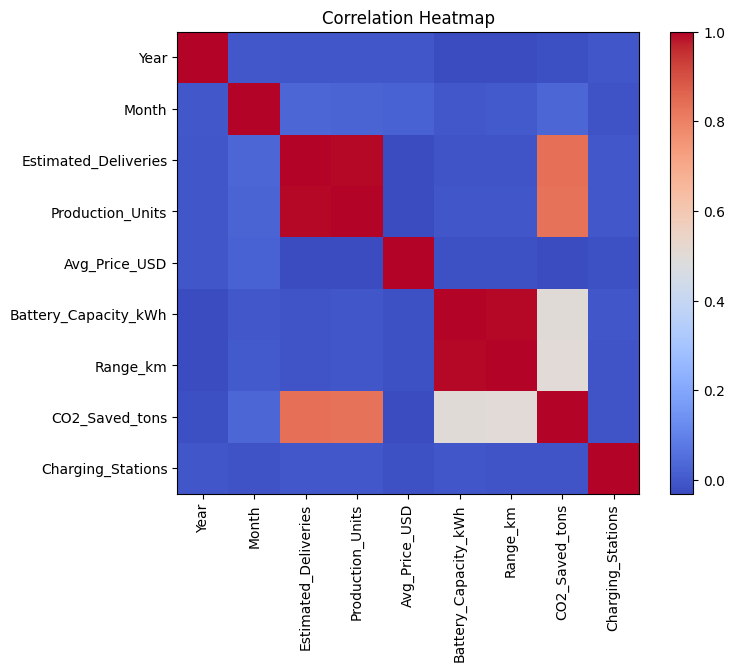

In [13]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

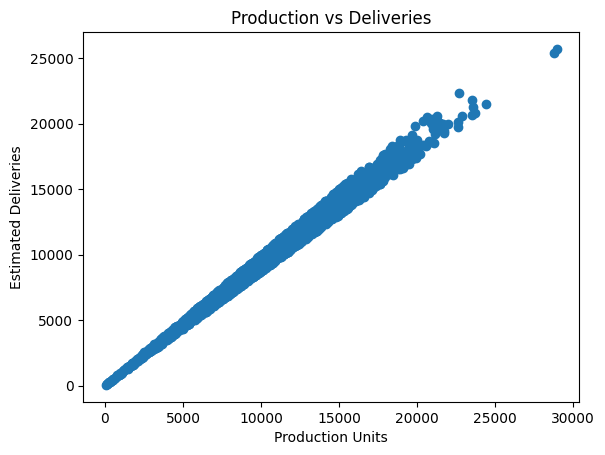

In [14]:
plt.scatter(df["Production_Units"], df["Estimated_Deliveries"])

plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.title("Production vs Deliveries")

plt.show()

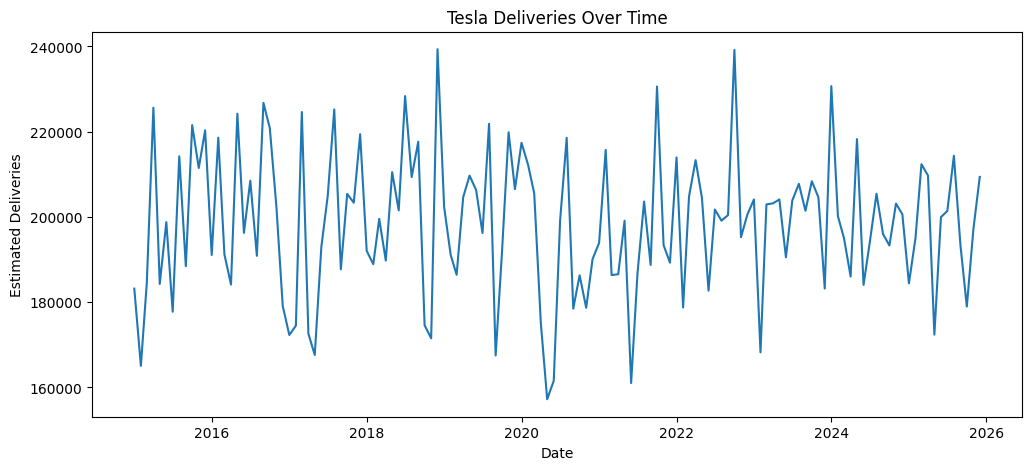

In [15]:
monthly = df.groupby(["Year","Month"])["Estimated_Deliveries"].sum().reset_index()

monthly["Date"] = pd.to_datetime(monthly["Year"].astype(str) + "-" + monthly["Month"].astype(str))

plt.figure(figsize=(12,5))
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"])

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

In [16]:
encoder = LabelEncoder()

df["Region"] = encoder.fit_transform(df["Region"])
df["Model"] = encoder.fit_transform(df["Model"])
df["Source_Type"] = encoder.fit_transform(df["Source_Type"])

In [17]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean(), inplace=True)

/tmp/ipykernel_11667/2553558995.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean(), inplace=True)


In [18]:
df["Rolling_Mean_3"] = df["Estimated_Deliveries"].rolling(3).mean()

df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean(), inplace=True)

/tmp/ipykernel_11667/2396320251.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean(), inplace=True)


In [19]:
X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

In [20]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [21]:
model = LinearRegression()

model.fit(X_train,y_train)

prediction = model.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test,prediction)

rmse = np.sqrt(mean_squared_error(y_test,prediction))

r2 = r2_score(y_test,prediction)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 310.3345215398842
RMSE: 375.5646664534478
R2: 0.9908058721380986


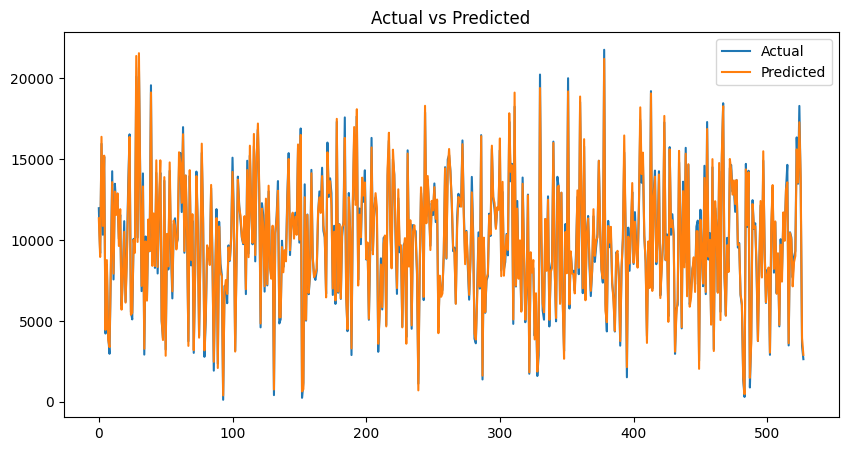

In [24]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values,label="Actual")
plt.plot(prediction,label="Predicted")

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

In [25]:
scores = cross_val_score(model,X,y,cv=5)

print(scores)

print("Average:",scores.mean())

[0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]
Average: 0.9903849476659861


In [26]:
rf = RandomForestRegressor(random_state=42)

In [29]:
param_grid = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(rf,param_grid,cv=5)

grid.fit(X_train,y_train)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': None, 'n_estimators': 50}
0.9882516742839895


In [28]:
best = grid.best_estimator_

pred = best.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
print("R2:",r2_score(y_test,pred))

MAE: 303.85833333333335
RMSE: 388.5512760612014
R2: 0.99015903323468


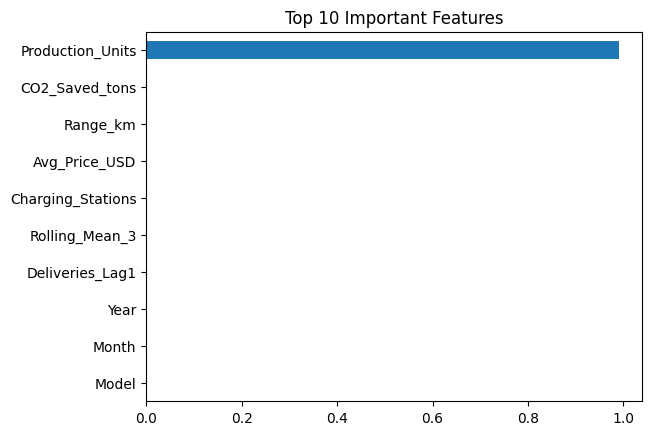

In [30]:
importance = pd.Series(best.feature_importances_,index=X.columns)

importance.sort_values().tail(10).plot(kind="barh")

plt.title("Top 10 Important Features")

plt.show()

In [31]:
result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:",result[0])

print("P-value:",result[1])

if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

ADF Statistic: -53.82661259715622
P-value: 0.0
Stationary


In [32]:
forecast = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":pred
})

forecast["Error %"] = abs((forecast["Actual"]-forecast["Predicted"])/forecast["Actual"])*100

forecast.head(20)

,Actual,Predicted,Error %
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


In [33]:
df.to_csv("processed_tesla_dataset.csv",index=False)